<center><h1>Dang_Dennis_HW6</h1></center>

Name: Dennis Dang
<br>
Github Username: dennisdang5
<br>
USC ID: 1764806509

## 1. Tree-Based Methods

Import packages

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

### (a) Download the APS Failure data

In [2]:
# Read in csv
aps_failure_train_set = pd.read_csv('../data/aps_failure_training_set.csv', na_values='na', skiprows=20)
aps_failure_test_set = pd.read_csv('../data/aps_failure_test_set.csv', na_values='na', skiprows=20)

# Change class labels to binary
aps_failure_train_set['class'] = aps_failure_train_set['class'].map({'pos':1, 'neg':0})
aps_failure_test_set['class'] = aps_failure_test_set['class'].map({'pos':1, 'neg':0})

# Data exploration print statements
# print(aps_failure_train_set.shape)
# print(aps_failure_test_set.shape)
# print(aps_failure_train_set.dtypes)
# print(aps_failure_test_set.dtypes)
# print(aps_failure_train_set.head())
# print(aps_failure_test_set.head())
# print(aps_failure_train_set['class'].value_counts())
# print(aps_failure_train_set['class'].isnull().sum())

##### AI Prompts Used (Claude Opus 4.6)
(a) When reading in a csv with pandas library how do I skip a certain amount of rows that contain metadata for my dataset so the parser just reads the data?

(a) I'm a student learning machine learning and working on an assignment for class, I want you to walk me through a set of problems without giving me the immediate code and teach me. In the future I need to do tree based classification. I just read in the data correctly and everything checks out but I should encode my classes of 'neg' and 'pos' to binary. Should I just use a label encoder? Walk me through this.

### (b) Data Preparation

#### (i) Research what types of techniques are usually used

##### Answer
* There are many different ways to deal with missing values in our data that fall under the category of removal or imputation based. Since were dealing with so many missing values we should not drop rows or drop columns
* Mean/Median imputation = replace NA with the column's mean or median such that it's preferred when data is skewed
* Mode imputation = replace NA with the most frequent value
* KNN imputation = replace NA with values based on similar rows but requires a lot more computation
* Iterative imputation = we model each feature as a function of other features
* For this dataset I will be doing median imputation because sensor data is often skewed thus using the median would help combat that when compared to the mean being distorted by outliers.

In [3]:
# Features split for train and test set
X_train = aps_failure_train_set.drop(columns=['class'])
y_train = aps_failure_train_set['class']
X_test = aps_failure_test_set.drop(columns=['class'])
y_test = aps_failure_test_set['class']

# Median imputation
median_imputer = SimpleImputer(strategy='median')
X_train_imputed = median_imputer.fit_transform(X_train)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns) # SimpleImputer returns a numpy array with no column names thus we should return it back to a dataframe
X_test_imputed = median_imputer.transform(X_test)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

##### AI Prompts Used (Claude Opus 4.6)
(b.i) My dataset contains alot of missing values such that I do not want to just discard the rows. What data imputation methods should I use in order to fix the amount of missing values? I do know that you can use mean or median but in my case what would be the best? Walk me through this as if you're teaching me.

(b.i) How can I tell which data imputation method I should use? Should I examine the column that has the most NA values and go from there?

(b.i) I will be doing median data imputation. Walk me through how I would do this without giving me the immediate code. I do know I should fit the imputer only on the training set then transform the test set. I should also do my feature split before imputing right?

#### (ii) Calculate the coefficient of variation

In [4]:
coefficient_of_variation_CV = X_train_imputed.std() / X_train_imputed.mean()
print(coefficient_of_variation_CV.sort_values(ascending=False))
# print(X_train_imputed['cd_000'].nunique())

cf_000    244.887517
co_000    244.507385
ad_000    244.322816
cs_009    237.930554
dh_000    123.216097
             ...    
bo_000      0.792383
bp_000      0.753392
bq_000      0.718534
br_000      0.689112
cd_000      0.000000
Length: 170, dtype: float64


##### AI Prompts Used (Claude Opus 4.6)
(b.ii) What does coefficient of variation mean again after I did the calculation of std / mean? How do I interpret it, if it is high does that mean the feature has a high variance relative to its mean?

#### (iii) Plot a correlation matrix

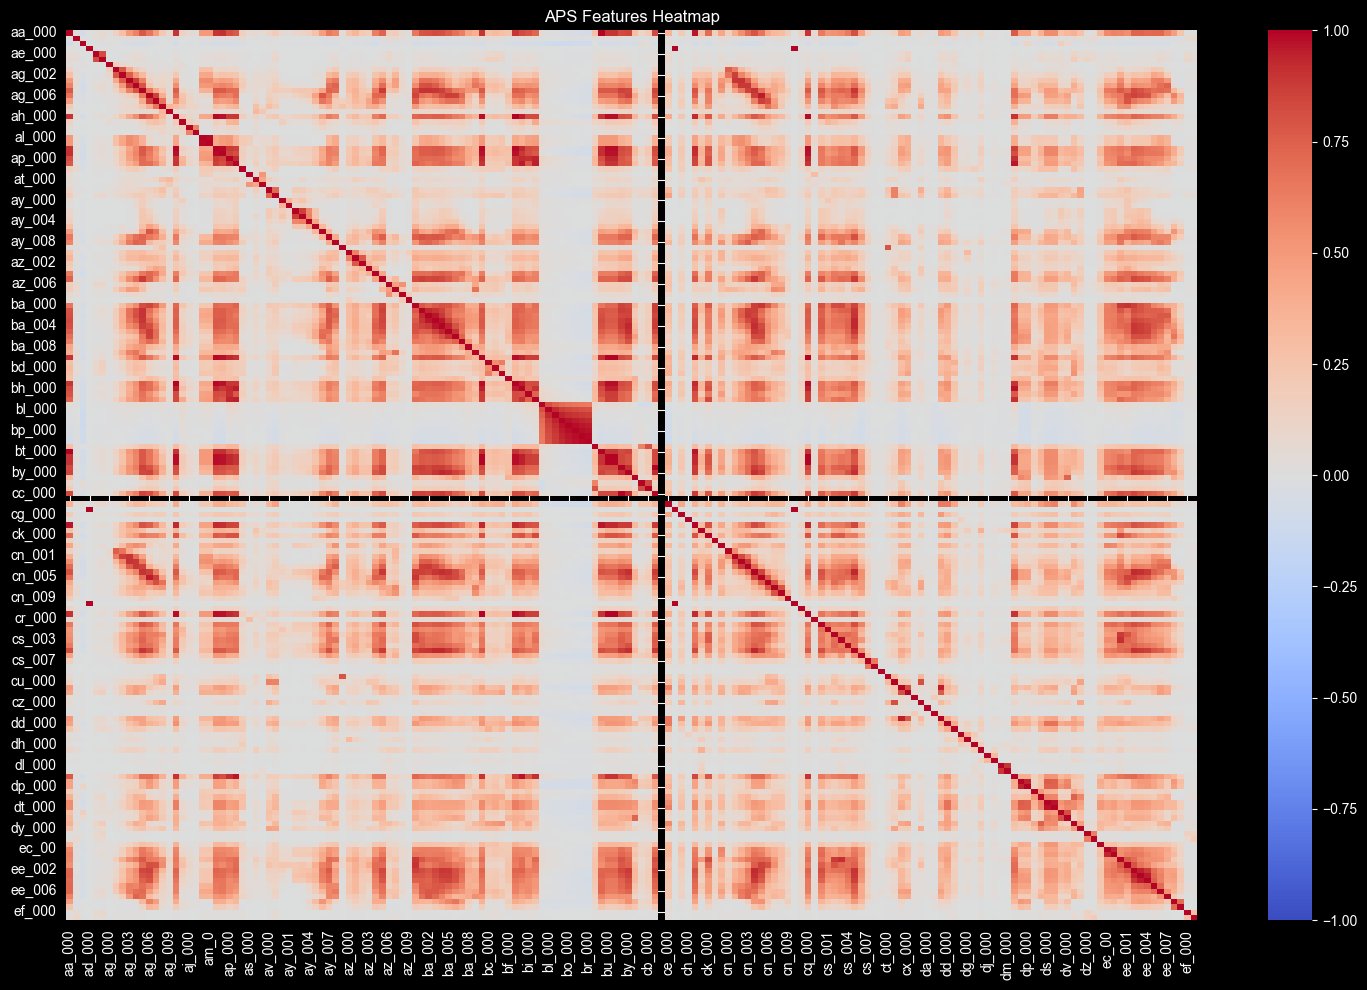

In [5]:
# Plot creation
plt.figure(figsize=(15,10))
sns.heatmap(X_train_imputed.corr(), cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title('APS Features Heatmap')
plt.tight_layout()
plt.show()

In [6]:
correlation_matrix = X_train_imputed.corr()
negative_correlation = correlation_matrix[correlation_matrix < 0].stack().sort_values()
print(negative_correlation.head(20))

bn_000  ac_000   -0.105625
ac_000  bn_000   -0.105625
        bm_000   -0.103495
bm_000  ac_000   -0.103495
ac_000  bo_000   -0.103070
bo_000  ac_000   -0.103070
bl_000  ac_000   -0.100081
ac_000  bl_000   -0.100081
br_000  ce_000   -0.097438
ce_000  br_000   -0.097438
bp_000  ac_000   -0.097160
ac_000  bp_000   -0.097160
bq_000  ce_000   -0.095803
ce_000  bq_000   -0.095803
ac_000  bq_000   -0.092935
bq_000  ac_000   -0.092935
bp_000  ce_000   -0.092254
ce_000  bp_000   -0.092254
br_000  ac_000   -0.090283
ac_000  br_000   -0.090283
dtype: float64


##### Observations
* There is a strong correlation between features in the same bin especially ba_000 through bt_000
* There are very few weakly negative correlated features that exists in our dataset, however, there are no strongly negative correlated features
* There is a black crosshair line near cc_000 / cd_000 because I found earlier that cd_000 has only 1 unique value throughout the whole column thus that column is constant

##### AI Prompts Used (Claude Opus 4.6)
(b.iii) I need to plot a correlation matrix of my features. Lets use a seaborn heatmap and walk me through this problem without giving me the immediate code.

(b.iii) The heatmap I created has block line just going across similar to a crosshair. What is causing this?

(b.iii) How can I show the negative correlated features since its relatively hard to see it in my heatmap? Walk me through this without giving me the immediate code.

#### (iv) Make scatter plots and box plots

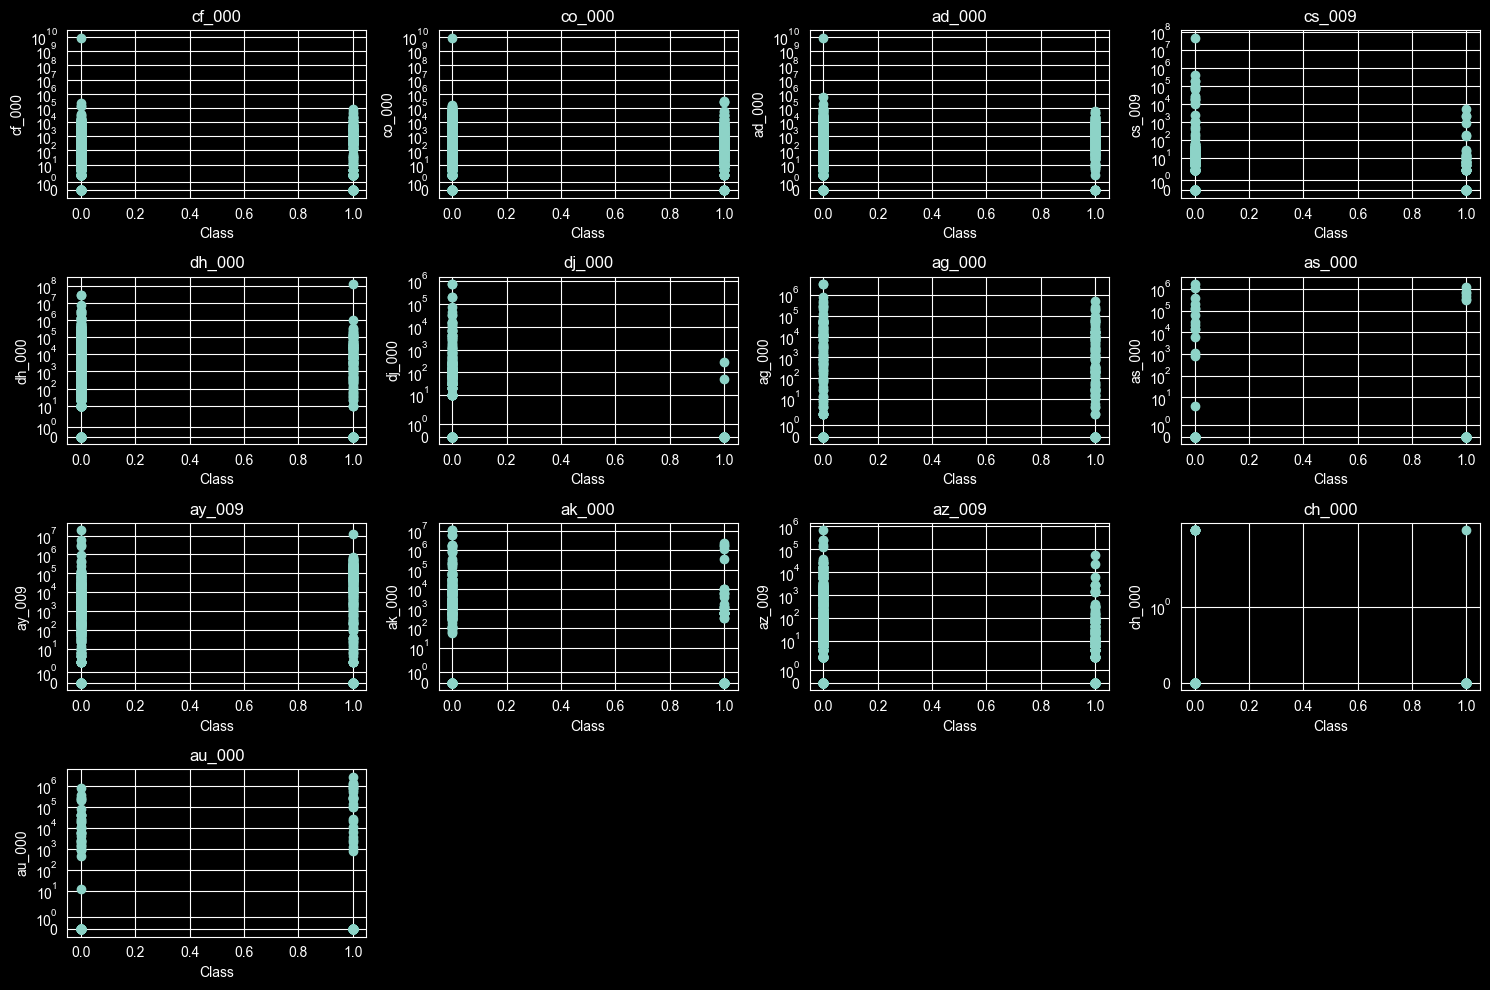

In [7]:
# Floor sqrt(170) = 13
top_13_features = coefficient_of_variation_CV.sort_values(ascending=False).head(13)
# print(top_13_features.index)

# Scatterplot creation
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(15,10))
ax = ax.flatten()
for i, feature_name in enumerate(top_13_features.index):
    ax[i].scatter(y_train, X_train_imputed[feature_name])
    ax[i].set_xlabel('Class')
    ax[i].set_ylabel(feature_name)
    ax[i].set_title(feature_name)
    ax[i].set_yscale('symlog')

for j in range(len(top_13_features), len(ax)):
    plt.delaxes(ax[j])

plt.tight_layout()
plt.show()

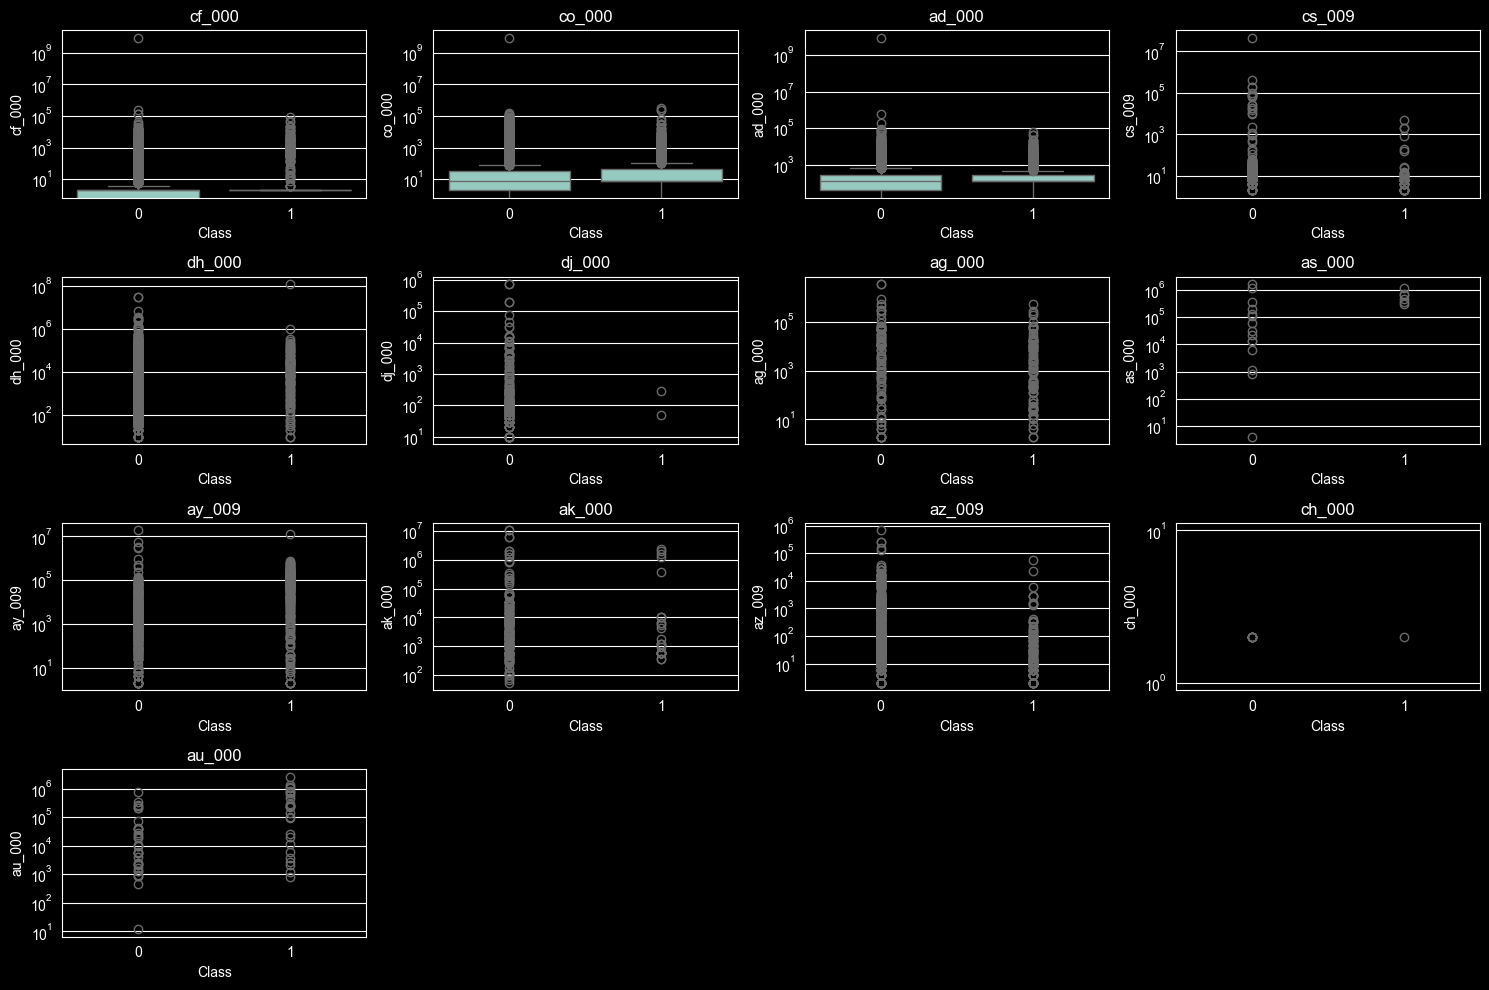

In [8]:
# Boxplot creation
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(15,10))
ax = ax.flatten()
for i, feature_name in enumerate(top_13_features.index):
    sns.boxplot(x=y_train, y=X_train_imputed[feature_name], ax=ax[i])
    ax[i].set_xlabel('Class')
    ax[i].set_ylabel(feature_name)
    ax[i].set_title(feature_name)
    ax[i].set_yscale('log')

for j in range(len(top_13_features), len(ax)):
    plt.delaxes(ax[j])

plt.tight_layout()
plt.show()

##### Answer
* No we cannot draw any significance conclusions just based on the scatterplot alone due to the fact that we cannot see the distribution in a scatterplot easily. Furthermore, our data does have a huge class imbalance as stated by the researchers, there are 59000 class 0 and 1000 class 1 thus making it hard to make conclusions because there are just so many more data points part of class 0.
* Lastly, we can't come to a conclusion on feature significance just based on the scatter plot because it only examines one feature at a time. There is a possibility that a combination of those features can form a good predictor.

##### AI Prompts Used (Claude Opus 4.6)
(b.iv) I now need to make scatter and box plot of the floor of sqrt 170 features with the highest CV. Furthermore, will I be able to draw a conclusion on the significance of those features after plotting? Walk me through this without giving me the immediate code.

(b.iv) If I have 4x4 subplots but only 13 features plots how can I remove the unused subplots. Walk me through this without giving me the immediate code.

(b.iv) Should I use a log scale on yaxis on my scatterplots because some features have very large numbers?

(b.iv) After creating my scatter plots, how do I interpret the plots and what should I look for? I'm assuming that we should see if a feature predominantly is class 0 if a feature has many datapoints with high values as an example.

(b.iv) How would I create boxplots would it be the same steps as the scatterplots? Walk me  through this without giving me the immediate code.

(b.iv) How come when I created my boxplots there are subplots that don't have a box does that mean a lot of the data is concentrated in one area?

#### (v) Is this data set imbalanced?

In [9]:
print(y_train.value_counts())

class
0    59000
1     1000
Name: count, dtype: int64


##### Answer
* Yes, there is a heavy class imbalance such that there are 59000 class 0 (negative) and 1000 class 1 (positive)
* Since the imbalance is so great our model can just predict class 0 for everything and still achieve a high accuracy rate

##### AI Prompts Used (Claude Opus 4.6)
(b.v) If our class is heavily imbalanced can't the model is just predict in the majority class and still get a high accuracy?

### (c) Train a random forest

In [10]:
# Model creation fit
random_forest_imbalanced_classifier = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
random_forest_imbalanced_classifier.fit(X_train_imputed, y_train)

# Model predictions and probability
y_train_predictions = random_forest_imbalanced_classifier.predict(X_train_imputed)
y_train_probability = random_forest_imbalanced_classifier.predict_proba(X_train_imputed)[:,1]
y_test_predictions = random_forest_imbalanced_classifier.predict(X_test_imputed)
y_test_probability = random_forest_imbalanced_classifier.predict_proba(X_test_imputed)[:,1]

[[59000     0]
 [    1   999]]


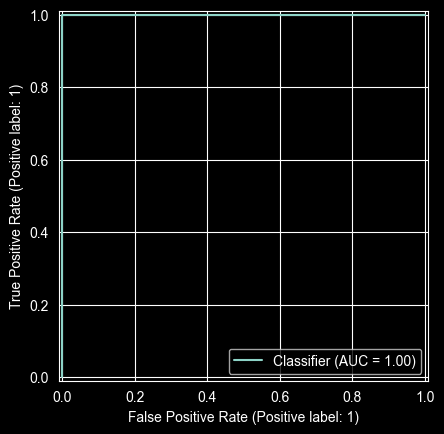

In [11]:
# Training confusion matrix and ROC/AUC creation
rf_train_cm = confusion_matrix(y_train, y_train_predictions)
print(rf_train_cm)
RocCurveDisplay.from_predictions(y_train, y_train_probability)
plt.show()

[[15610    15]
 [  106   269]]


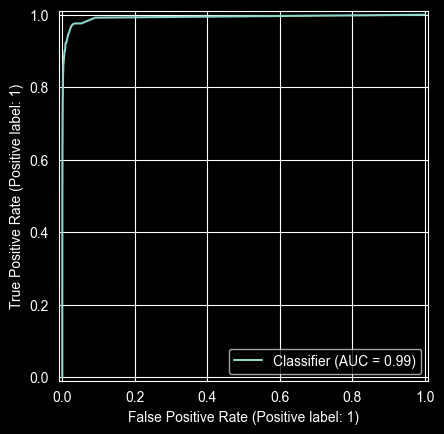

In [12]:
# Test confusion matrix and ROC/AUC creation
rf_test_cm = confusion_matrix(y_test, y_test_predictions)
print(rf_test_cm)
RocCurveDisplay.from_predictions(y_test, y_test_probability)
plt.show()

In [13]:
# Misclassification rate
rf_imbalance_train_misclassification = 1 - accuracy_score(y_train, y_train_predictions)
rf_imbalance_test_misclassification = 1 - accuracy_score(y_test, y_test_predictions)
print(f'Random Forest Imbalance Train Misclassification: {rf_imbalance_train_misclassification}')
print(f'Random Forest Imbalance Test Misclassification: {rf_imbalance_test_misclassification}')

# Out of bag error
print(f'Out of Bag Score: {random_forest_imbalanced_classifier.oob_score_}')
print(f'Out of Bag Error: {1 - random_forest_imbalanced_classifier.oob_score_}')

Random Forest Imbalance Train Misclassification: 1.666666666666483e-05
Random Forest Imbalance Test Misclassification: 0.0075625000000000275
Out of Bag Score: 0.9938333333333333
Out of Bag Error: 0.006166666666666654


##### Answer
* The random forest imbalanced test misclassification was 0.76%, whereas, the out of bag error was 0.62% which is close to the test misclassification rate such that it is a reliable generalization error that doesn't require a validation set.

##### AI Prompts Used (Claude Opus 4.6)
(c) I need to train a random forest classifier on this data set and should not compensate for class imbalance. Furthermore, I need to calculate the confusion matrix, ROC, AUC, and misclassification for the training and test sets. Lastly, I need to calculate out of bag error estimate for the random forest and compare it to the test error. Walk me the through this without giving me the immediate code and teach me.

(c) Explain to me what out of bag error is and how does the random forest calculate it?

(c) What are each of the parameters in the RandomForestClassifier of sklearn?

(c) I should probably get the probability and predictions of the train/test sets right in order to do confusion matrix / roc curve.

(c) Walk me through how to create roc/auc curve without giving me the immediate code.

(c) How do you calculate out of bag error? Teach me without giving me the immediate code and what does out of bag error even mean.

(c) Teach me how to compare OOB and test misclassification rate.

### (d) Research class imbalance in random forest

In [14]:
# Random forest balanced model creation
random_forest_balanced_classifier = RandomForestClassifier(n_estimators=100, oob_score=True, class_weight='balanced', random_state=42)
random_forest_balanced_classifier.fit(X_train_imputed, y_train)

# Random forest balanced model predictions
y_train_predictions = random_forest_balanced_classifier.predict(X_train_imputed)
y_train_probability = random_forest_balanced_classifier.predict_proba(X_train_imputed)[:, 1]
y_test_predictions = random_forest_balanced_classifier.predict(X_test_imputed)
y_test_probability = random_forest_balanced_classifier.predict_proba(X_test_imputed)[:, 1]

[[59000     0]
 [    1   999]]


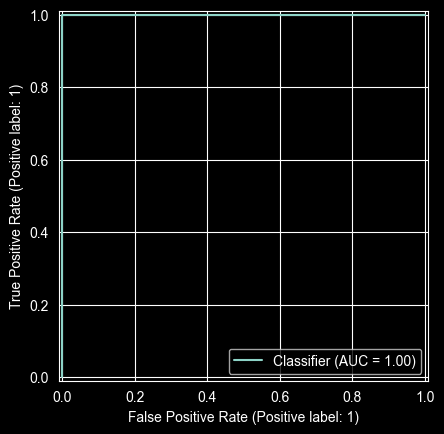

In [15]:
# Random forest balanced train confusion matrix and AUC/ROC creation
rf_balanced_train_cm = confusion_matrix(y_train, y_train_predictions)
print(rf_balanced_train_cm)
RocCurveDisplay.from_predictions(y_train, y_train_probability)
plt.show()

[[15611    14]
 [  160   215]]


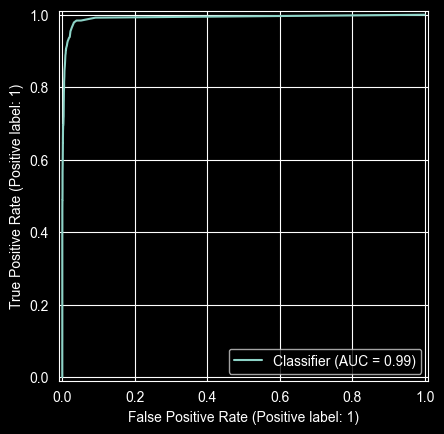

In [16]:
# Random forest balanced test confusion matrix and AUC/ROC creation
rf_balanced_test_cm = confusion_matrix(y_test, y_test_predictions)
print(rf_balanced_test_cm)
RocCurveDisplay.from_predictions(y_test, y_test_probability)
plt.show()

In [17]:
# Misclassification rate
rf_balance_train_misclassification = 1 - accuracy_score(y_train, y_train_predictions)
rf_balance_test_misclassification = 1 - accuracy_score(y_test, y_test_predictions)
print(f'Random Forest Balance Train Misclassification: {rf_balance_train_misclassification}')
print(f'Random Forest Balance Test Misclassification: {rf_balance_test_misclassification}')

# Out of bag error
print(f'Out of Bag Score: {random_forest_balanced_classifier.oob_score_}')
print(f'Out of Bag Error: {1 - random_forest_balanced_classifier.oob_score_}')

Random Forest Balance Train Misclassification: 1.666666666666483e-05
Random Forest Balance Test Misclassification: 0.010874999999999968
Out of Bag Score: 0.9918
Out of Bag Error: 0.008199999999999985


##### Answer
* The balanced test misclassification was 1.08%, whereas, the out of bag error was 0.81% thus the out of bag error can be reasonable as a generalization estimate
* After balancing the classes I found that the balanced test misclassification went up actually when compared to the imbalanced, from 0.76% to 1.08% thus balancing was worse than the imbalanced classes
* The test AUC remained the same for both balance and imbalance
* Lastly, the balance classifier encountered more false negative cases when compared to the imbalanced but according to the researchers false negatives in this case are weighed worse than false positives. In conclusion, the balanced classifier was worse than the imbalanced classifier.

##### AI Prompts Used (Claude Opus 4.6)
(d) How are class imbalances addressed in random forests? Furthermore, I should compensate the class imbalance and repeat creating a random forest model. Walk me through this without giving me the immediate code and teach me.

(d) Explain to me the difference between balanced and balanced_subsample for the parameters of random forest classifier in sklearn. Is the goal to punish false negatives more just due to the fact that it costs us more when compared to false positive?

(d) I balanced the random forest classifier but the amount of false negatives went up is that correct?

### (e) XGBoost and Model Trees

In [18]:
np.random.seed(42)
# XGBoost classifier creation and fit
alphas = {'reg_alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
xgb_model = XGBClassifier(booster='gblinear', objective='binary:logistic', random_state=42, n_jobs=1)
grid_search_xgb_model = GridSearchCV(xgb_model, alphas, cv=10, scoring='roc_auc')
grid_search_xgb_model.fit(X_train_imputed, y_train)

# Predictions
y_train_predictions = grid_search_xgb_model.predict(X_train_imputed)
y_train_probability = grid_search_xgb_model.predict_proba(X_train_imputed)[:,1]
y_test_predictions = grid_search_xgb_model.predict(X_test_imputed)
y_test_probability = grid_search_xgb_model.predict_proba(X_test_imputed)[:,1]

print(f'Optimal Regularization Term: {grid_search_xgb_model.best_params_['reg_alpha']}')
print(f'Optimal CV AUC: {grid_search_xgb_model.best_score_}')

Optimal Regularization Term: 1
Optimal CV AUC: 0.8326864406779662


[[58550   450]
 [  197   803]]


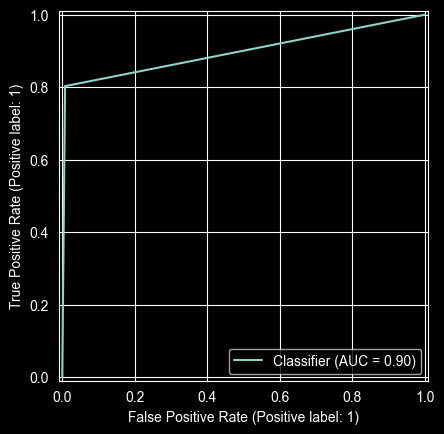

In [19]:
# Train confusion matrix and ROC/AUV creation
xgb_imbalanced_train_cm = confusion_matrix(y_train, y_train_predictions)
print(xgb_imbalanced_train_cm)
RocCurveDisplay.from_predictions(y_train, y_train_probability)
plt.show()

[[15491   134]
 [   64   311]]


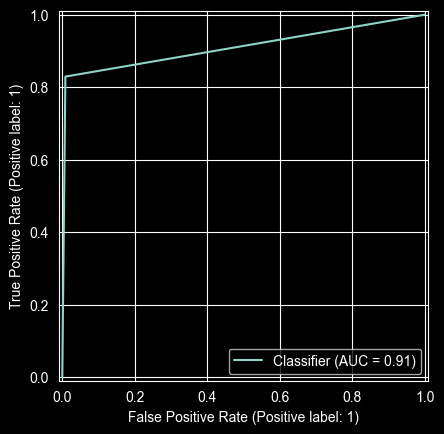

In [20]:
# Test confusion matrix and ROC/AUV creation
xgb_imbalanced_test_cm = confusion_matrix(y_test, y_test_predictions)
print(xgb_imbalanced_test_cm)
RocCurveDisplay.from_predictions(y_test, y_test_probability)
plt.show()

In [21]:
optimal_xgb = grid_search_xgb_model.best_estimator_ # Uses the optimal regularization term calculated prior
cv_scores = cross_val_score(optimal_xgb, X_train_imputed, y_train, cv=10, scoring='accuracy')
cv_error = 1 - cv_scores.mean()
test_error = 1 - accuracy_score(y_test, y_test_predictions)

print(f'XGB Classifier CV Error: {cv_error}')
print(f'XGB Classifier Test Error: {test_error}')

XGB Classifier CV Error: 0.011016666666666786
XGB Classifier Test Error: 0.012375000000000025


##### Answer
* The cross validated error was 1.11%, whereas, the test error was 1.23%
* Since they're extremely close we can say that cross validation did give us a good estimate of the generalized performance of the model

##### AI Prompts Used (Claude Opus 4.6)
(e) Instead of using regular tree splits on a single feature I need to use a linear combination of all features at each split. Furthermore, I need to use L1-penalized logistic regression as well as using XGBoost. I need to determine the regularization term using cross validation and then train the model without compensation of class imbalance. I should use one of 5 fold, 10 fold, and leave one out corss validation methods to estimate the error of the trained model and compare it with test. Lastly, I need to create confusion matrix, ROC/AUC for training and test sets. Walk me through this step by step teaching me without giving me the immediate code.

(e) Should I use GridSearchCV in order to find the optimal alphas for my XGBoost classifier?

(e) What should my scoring metric be for my classifier?

(e) How do I get the optimal CV error so that I can test it against my test error?

(e) For my classifier scoring shouldn't I use accuracy rather than AUC_ROC?

(e) If I use AUC_ROC as my scoring how can I report the CV error vs test error? Walk me through this without giving me the immediate answer.

(e) I keep rerunning my XGBoost classifier model and get different regularization terms and even error rates whats going on? I set the random_state already too.

### (f) Use SMOTE to pre-process your data

In [22]:
# Model and pipeline creation
alphas = {'xgb__reg_alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]}
smote_xgb_classifier_pipeline = ImbPipeline([('smote', SMOTE(random_state=42)), ('xgb', XGBClassifier(booster='gblinear', objective='binary:logistic', random_state=42))])
grid_search_xgb_SMOTE_model = GridSearchCV(smote_xgb_classifier_pipeline, alphas, cv=10, scoring='roc_auc')
grid_search_xgb_SMOTE_model.fit(X_train_imputed, y_train)

# Predictions
y_train_predictions = grid_search_xgb_SMOTE_model.predict(X_train_imputed)
y_train_probability = grid_search_xgb_SMOTE_model.predict_proba(X_train_imputed)[:,1]
y_test_predictions = grid_search_xgb_SMOTE_model.predict(X_test_imputed)
y_test_probability = grid_search_xgb_SMOTE_model.predict_proba(X_test_imputed)[:,1]

print(f'Optimal Regularization Term: {grid_search_xgb_SMOTE_model.best_params_['xgb__reg_alpha']}')
print(f'Optimal CV AUC: {grid_search_xgb_SMOTE_model.best_score_}')

Optimal Regularization Term: 500
Optimal CV AUC: 0.9796577966101696


[[57481  1519]
 [   84   916]]


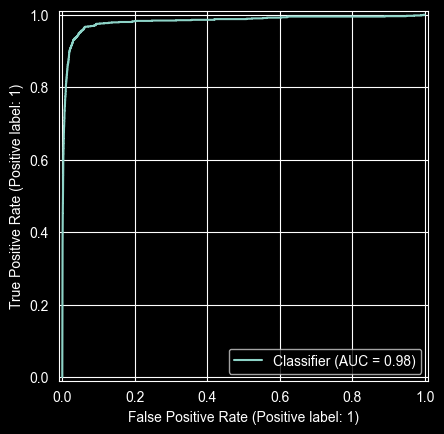

In [23]:
# Train confusion matrix and ROC/AUV creation
xgb_SMOTE_train_cm = confusion_matrix(y_train, y_train_predictions)
print(xgb_SMOTE_train_cm)
RocCurveDisplay.from_predictions(y_train, y_train_probability)
plt.show()

[[15245   380]
 [   34   341]]


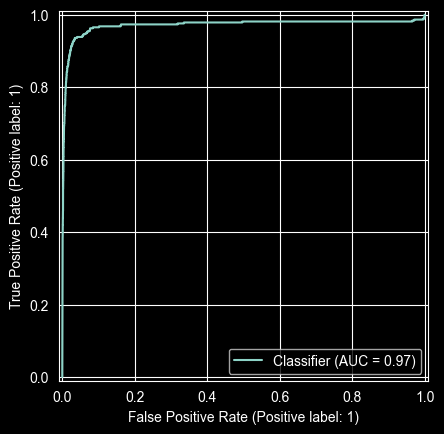

In [24]:
# Test confusion matrix and ROC/AUV creation
xgb_SMOTE_test_cm = confusion_matrix(y_test, y_test_predictions)
print(xgb_SMOTE_test_cm)
RocCurveDisplay.from_predictions(y_test, y_test_probability)
plt.show()

In [25]:
optimal_xgb_SMOTE = grid_search_xgb_SMOTE_model.best_estimator_ # Uses the optimal regularization term calculated prior
cv_scores = cross_val_score(optimal_xgb_SMOTE, X_train_imputed, y_train, cv=10, scoring='accuracy')
cv_error = 1 - cv_scores.mean()
test_error = 1 - accuracy_score(y_test, y_test_predictions)

print(f'XGB SMOTE Classifier CV Error: {cv_error}')
print(f'XGB SMOTE Classifier Test Error: {test_error}')

XGB SMOTE Classifier CV Error: 0.022816666666666707
XGB SMOTE Classifier Test Error: 0.02587499999999998


##### Answer
* The cross validated error was 2.28%, whereas, the test error was 2.58%
* Since the test and CV error were extremely close we can say that cross validation did give us a good estimate of the generalized performance of the model
* SMOTE XGBoost did perform worse than the non SMOTE XGBoost model, the test error for SMOTE XGBoost was 2.58% and non SMOTE XGBoost was 1.23%
* However, there is a huge caveat for this because the SMOTE XGBoost model had a significant decrease in false negatives of 30 when compared to the false negatives of non SMOTE XGBoost model of 64 in the test set. This is significant because according to the researchers a false negative costed the truck company more when compared to a false positive, so if were purely talking about the cost metric then the SMOTE XGBoost did perform better when compared to the non SMOTE XGBoost model

##### AI Prompts Used (Claude Opus 4.6)
(f) I now need to use SMOTE to pre process the data to compensate for class imbalance. Then train XGBoost with l1 logistic regression at each node. Furthermore, I need to determine the regularization term using cross validation (10 fold) and estimate the error of the trained model and compare it with test. Then I need to create confusion matrix, ROC/AUC for training and test sets. Then compare the imbalanced case vs SMOTE case. Walk me through this without giving me the immediate code and teach me.

(f) Explain to me simply what SMOTE is and how does it work plus its use cases.

(f) Im assuming I should use SMOTE inside the cross validation step rather than before doing any cross validation.

(f) FOr the SMOTE pipeline do I just create a XGBoost classifier in it then go through the whole grid search CV similar to before?

(f) I found that the model uses alpha=100 should I extend the range in order to see if there is a better alpha than the edge?

(f) Lets just say in a scenario where cost metric doesnt matter is it safe to conclude that random forest is better with class imbalance than xgboost?

(f) My SMOTE error rate was higher than the imbalanced XGBoost model is that correct? I did notice that the false negatives rate did go down significantly.

## 2. ISLR 6.6.3

##### Answer
(a) iv. steadily decrease, the reason behind this is that increasing the model flexibility with s cannot make the training RSS get worse since the less constrained model includes the constrained model.

(b) ii. decrease initially then increase in a U shape, the reason behind this is that when s = 0 there would be underfitting thus increasing the flexibility through s would allow us to capture the data points. However, if we keep increasing s then overfitting in training can occur such that the model would fit the noise of training and be terrible at generalizing to test thus increasing the test RSS.

(c) iii. steadily increase, the reason behind this is that when s = 0 the model is just the mean but as you add more flexibility the model becomes more sensitive to the training data, therefore, the coefficients of the model would move around more when s increases sine they are more flexible.

(d) iv. steadily decrease, the reason behind this is that when s = 0 the model is the mean thus having a high bias but as we increase flexibility the model can then capture the relationship better thus decreasing bias.

(e) v. remain constant, the reason behind this is that the irreducible error is the act of god such that there will always be some kind of error/noise in the data where no tuning can fix it.

##### AI Prompts Used (Claude Opus 4.6)
(2) Suppose were estimating regression coefficients to a linear regression model I must use lasso regression such that were minimizing the RSS where the sum of absolute values of coefficients must be less than or equal to s. From my understanding when s = 0 it pushes all coefficient to zero, on the other hand, a large s allows the coefficients to do whatever it takes to minimize the RSS. Lets start with training RSS and how its affected when I increase s from 0. Walk me through this and teach me without giving me the answer.

(2) Adding more flexibility should decrease RSS in training for a bit but then increases RSS after while due to overfitting right?

(2) Increasing s would increase variance right?

(2) irreducible error should stay the same right because this is the unexplained epsilon that we cannot change right?

## 3. ISLR 6.6.5

##### Answer
(a) (y<sub>1</sub> - $\beta$<sub>1</sub>x<sub>11</sub> - $\beta$<sub>2</sub>x<sub>12</sub>)<sup>2</sup> + (y<sub>2</sub> - $\beta$<sub>1</sub>x<sub>21</sub> - $\beta$<sub>2</sub>x<sub>22</sub>)<sup>2</sup> + $\lambda$($\beta$<sub>1</sub><sup>2</sup> + $\beta$<sub>2</sub><sup>2</sup>)

(b) In order to show that the two beta hats are equal we can take the derivative of the ridge regression optimization equation with respect to both betas

$\frac{\partial}{\partial \beta_1}: -2x_{11}(y_1 - \beta_1 x_{11} - \beta_2 x_{12}) - 2x_{21}(y_2 - \beta_1 x_{21} - \beta_2 x_{22}) + 2\lambda\beta_1 = 0$

$\frac{\partial}{\partial \beta_2}: -2x_{12}(y_1 - \beta_1 x_{11} - \beta_2 x_{12}) - 2x_{22}(y_2 - \beta_1 x_{21} - \beta_2 x_{22}) + 2\lambda\beta_2 = 0$

since the predictors are identical we only need to focus on penalty terms and subtract one equation from the other resulting in

$2\lambda(\beta_1 - \beta_2) = 0$

we can see that in order to satisfy the equation both betas must be equal and that lambda is greater than 0 therefore

$\hat{\beta}_1 = \hat{\beta}_2$

(c) (y<sub>1</sub> - $\beta$<sub>1</sub>x<sub>11</sub> - $\beta$<sub>2</sub>x<sub>12</sub>)<sup>2</sup> + (y<sub>2</sub> - $\beta$<sub>1</sub>x<sub>21</sub> - $\beta$<sub>2</sub>x<sub>22</sub>)<sup>2</sup> + $\lambda$(|$\beta$<sub>1</sub>|+ |$\beta$<sub>2</sub>|)

(d) Since the predictors are identical the RSS depends only on the sum of ($\beta$<sub>1</sub> + $\beta$<sub>2</sub>) and not the individual values such that any split that gives the same sum of betas would produce the same RSS. No matter what both betas will have the same sign such that the penalty is the same regardless how you split them thus producing the same RSS. Let's say the optimal sum is c then all the examples below would give the same objective value.

$\beta$<sub>1</sub> = c, $\beta$<sub>2</sub> = 0

$\beta$<sub>1</sub> = 0, $\beta$<sub>2</sub> = c

the line segment would go from (0, c) to (c, 0), therefore, the solution is the line and not a single point

##### AI Prompts Used (Claude Opus 4.6)
(3) I have 2 observations 2 predictors and the variables are correlated and identical. The intercept beta hat zero is equal to zero and were centered at 0 for all points. I now need to compare ridge regression optimization vs lasso optimization in this problem setting. Walk me through this and teach me.

(3) I need to argue that in this case the ridge coefficient estimates satisfy beta hat 1 = beta hat 2. Walk me through this and teach me.

(3) Since the predictors are equal can I say that we just need to focus on the penalty and show that the betas are equal?

(3) I now need to argue that the lasso coefficients are not unique such that there are many possible ways to optimize our lasso problem. Walk me through this by teaching me.

(3) Basically for LASSO the solutions of the penalty are not unique but still produce the same RSS in the end for our problem?

## 4. ISLR 8.4.5

##### Answer
* Majority vote 6 red/10 vs 4 green/10, since we have the majority being red we would classify it as red
* Average probability (0.1 + 0.15 + 0.2 + 0.2 + 0.55 + 0.6 + 0.6 + 0.65 + 0.7 + 0.75) / 10 = 0.45 thus we would classify as green

##### AI Prompts Used (Claude Opus 4.6)
(4) If im doing a classification problem from a data set that contains red and green classes and then use a classification tree to produce 10 estimates of probability that the class is red given X the threshold would be 0.5 right such that anything greater than 0.5 would be red and anything below would be green right?

(4) When should i use average probability vs majority vote when classifying, doesn't average get skewed more when there are outliers?

## 5. ISLR 9.7.3

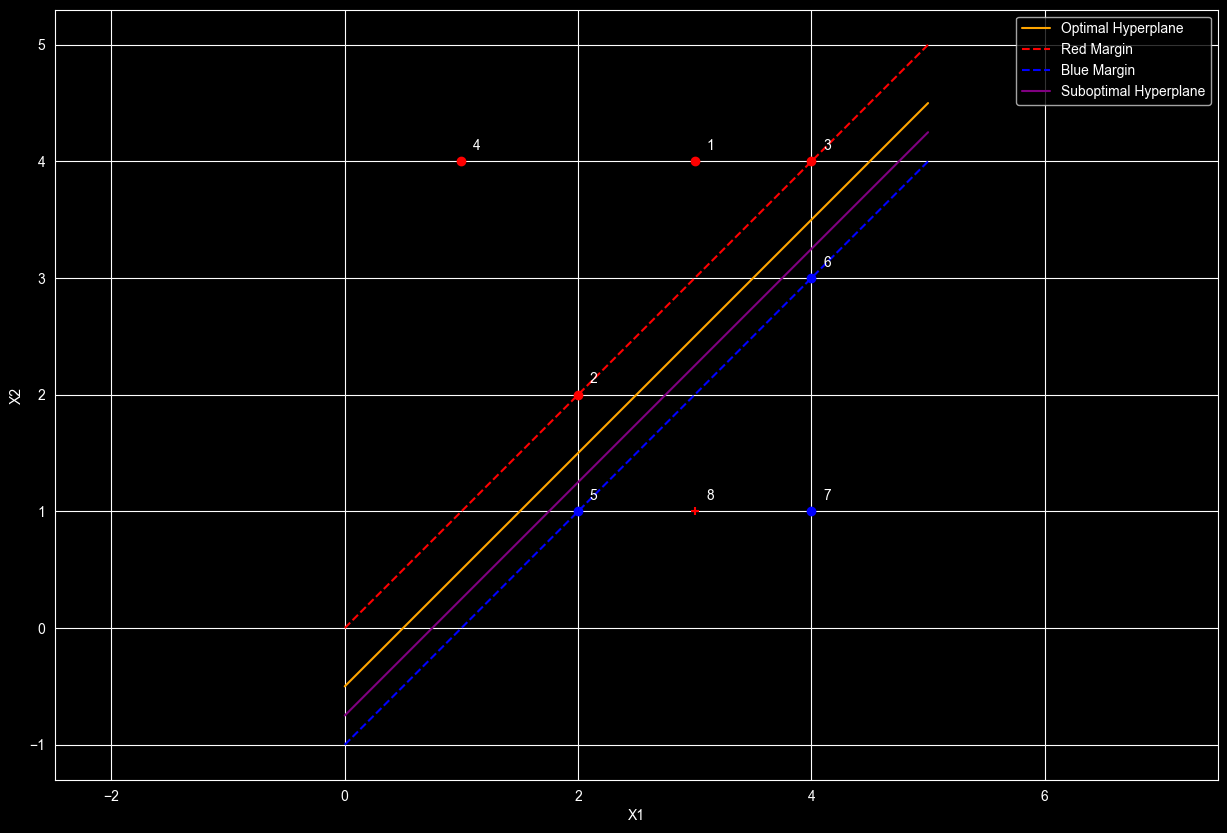

In [47]:
red_data_points = [(3,4), (2,2), (4,4), (1,4)]
blue_data_points = [(2,1), (4,3), (4,1)]

plt.figure(figsize=(15,10))
for i, (x1, x2) in enumerate(red_data_points, 1):
    plt.scatter(x1, x2, c='red')
    plt.annotate(f'{i}', (x1+0.1, x2+0.1))

for i, (x1, x2) in enumerate(blue_data_points, 5):
    plt.scatter(x1, x2, c='blue')
    plt.annotate(f'{i}', (x1+0.1, x2+0.1))

# Hyperplane creation
x1_line = np.linspace(0, 5, 100)
x2_line = x1_line - 0.5
plt.plot(x1_line, x2_line, color='orange', label='Optimal Hyperplane')

# Margin creation
x2_margin_red = x1_line
x2_margin_blue = x1_line - 1
plt.plot(x1_line, x2_margin_red, 'r--', label='Red Margin')
plt.plot(x1_line, x2_margin_blue, 'b--', label='Blue Margin')

# Suboptimal hyperplane creation
x2_suboptimal = x1_line - 0.75
plt.plot(x1_line, x2_suboptimal, color='purple', label='Suboptimal Hyperplane')

# Additional observation so the two classes are not separable by the hyperplane
plt.scatter(3, 1, c='red', marker='+')
plt.annotate('8', (3.1, 1.1))

plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.axis('equal')
plt.show()

##### Answer
(b) To find the hyperplane we must use points that are in two different classes but close to each other such that they form a pair. The two pairs would be (2,2) RED/(2,1) BLUE and (4,4) RED/(4,3) BLUE. We should then find the midpoints of the closest pairs

(2,2) and (2,1) -> (2, 1.5)

(4,4) and (4,3) -> (4, 3.5)

We then draw a line through the midpoints and the slope would be (3.5 - 1.5) / (4 -2) = 1

To find the equation of the hyperplane we use the point slope formula with a midpoint data point like (2, 1.5)

X<sub>2</sub> - 1.5 = 1(X<sub>1</sub> - 2)

X<sub>2</sub> = X<sub>1</sub> - 0.5

X<sub>1</sub> - X<sub>2</sub> - 0.5  = 0

$\beta_0 = -0.5, \beta_1 = 1, \beta_2 = -1$

(c) If I plug our points into our hyperplane equation of X<sub>1</sub> - X<sub>2</sub> - 0.5 we get

Red(1,4): 1 - 4 - 0.5 = -3.5

Red(2,2): 2- 2 - 0.5 = -0.5

Red(3,4) 3 - 4 - 0.5 = -1.5

Red(4,4) 4 - 4 - 0.5 = -0.5

Blue(2,1) 2 - 1 - 0.5 = 0.5

Blue(4,3) 4 - 3 - 0.5 = 0.5

Blue(4,1) 4 - 1 - 0.5 = 2.5

We should classify it red if -X<sub>1</sub> + X<sub>2</sub> + 0.5 > 0 and blue otherwise also
$\beta_0 = 0.5, \beta_1 = -1, \beta_2 = 1$

(d) Using the distance formula the distance between the two margin lines is 0.707 thus the distance from one margin to the maximal hyperplane is 0.354 on each side.

(e) The support vectors for the maximal margin classifier are the points that sit on the margin lines aka the points closest to the hyperplane for each class. Our support vectors are observation 2, 3, 5, and 6

(f) A slight movement in observation 7 would not affect the maximal margin hyperplane because this point is not a support vector, therefore, it would not change the margin lines or the hyperplane.

(g) Equation for suboptimal hyperplane X<sub>1</sub> - X<sub>2</sub> - 0.75 = 0

(h) I put a red point at (3,1) thus it sits in the blue region and that no straight line can now separate all blues and all red.

##### AI Prompts Used (Claude Opus 4.6)
(5) Given a data set with n = 7 and p = 2 we have associated class labels of red and blue. I need to sketch the optimal separating hyperplane and prove the equation for the hyperplane. Walk me through the code and problem without giving me the answer. All sketching can be done with code.

(5) Lets start by plotting the data points based on the class it found in. Walk me through this without giving me the immediate code.

(5) After plotting my points how do I create the optimal hyperplane and show its equation? Walk me through this without giving me the immediate code and answer.

(5) How do I indicate the margin for the maximal margin hyperplane? Walk me through this as if you're teaching me

(5) The margin would be the gap inbetween the classes from the closest point to the maximal margin hyperplane right?

(5) Points that don't support the maximal margin hyperplane would not affect the plane even if I move the point slightly is that correct?

(5) How would I sketch a suboptimal margin line? Can't I just move the intercept by a little bit in favor of one class?